In [1]:
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy import optimize
import skimage
from skimage import io as skio
from skimage.color import rgb2gray, rgb2hed
from skimage.filters import gaussian, median, sobel, frangi, threshold_otsu
from skimage.feature import structure_tensor
from skimage.measure import label, regionprops_table
from skimage.morphology import disk, remove_small_objects
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.transform import resize
from sklearn.decomposition import NMF
from sklearn.neighbors import NearestNeighbors
from pyimzml.ImzMLParser import ImzMLParser

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from pathlib import Path
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize
from skimage import transform, filters
try:
    import SimpleITK as sitk
    SITK_AVAILABLE = True
except ImportError:
    SITK_AVAILABLE = False
    print("WARNING: SimpleITK not installed. B-spline registration unavailable.")
    print("Install with: pip install SimpleITK")
from pyimzml.ImzMLParser import ImzMLParser
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

Loading kidney data set from skimage

In [2]:
kidney = skimage.data.kidney()

In [3]:
z_planes = np.arange(1,16,2)
slices = [kidney[z] for z in z_planes]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [26..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [46..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [62..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [66..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [63..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [37..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [16..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for 

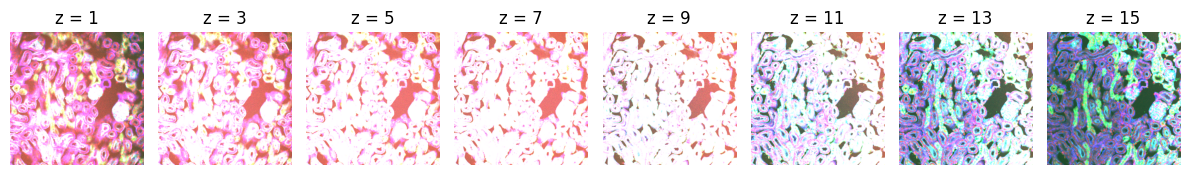

In [4]:
%matplotlib inline
fig, axes = plt.subplots(1, len(z_planes), figsize=(12, 4))

for ax, z in zip(axes, z_planes):
    img = kidney[z]  # shape: (y, x, 3)
    ax.imshow(img)
    ax.set_title(f"z = {z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [10..4095].


fixed image shape: (512, 512, 3)


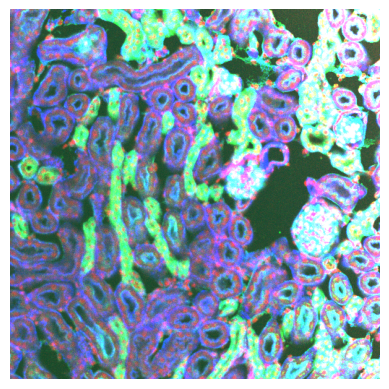

In [5]:
fixed_img = kidney[15]
print(f'fixed image shape: {fixed_img.shape}')
plt.imshow(fixed_img)
plt.axis('off')
plt.show()

In [6]:
import cv2

def crop_with_gui(image_path, offset=(0, 0)):
    img = cv2.imread(image_path)
    clone = img.copy()

    cropping = False
    start = None
    end = None
    rect_final = None

    def mouse(event, x, y, flags, param):
        nonlocal start, end, cropping, img, rect_final

        if event == cv2.EVENT_LBUTTONDOWN:
            start = (x, y)
            cropping = True

        elif event == cv2.EVENT_MOUSEMOVE and cropping:
            img = clone.copy()
            cv2.rectangle(img, start, (x, y), (0, 255, 0), 2)

        elif event == cv2.EVENT_LBUTTONUP:
            end = (x, y)
            cropping = False
            rect_final = (start[0], start[1], end[0], end[1])
            cv2.rectangle(img, start, end, (0, 255, 0), 2)

    cv2.namedWindow("Cropper")
    cv2.setMouseCallback("Cropper", mouse)

    while True:
        cv2.imshow("Cropper", img)
        key = cv2.waitKey(1)

        if key == 13 and rect_final is not None:  # ENTER
            x1, y1, x2, y2 = rect_final
            # Compute min/max
            x_min = min(x1, x2)
            x_max = max(x1, x2)
            y_min = min(y1, y2)
            y_max = max(y1, y2)

            # Local bbox always starts at 0,0
            bbox_local = (0, 0, x_max - x_min, y_max - y_min)

            # Global bbox uses offset
            ox, oy = offset
            bbox_global = (x_min + ox, y_min + oy, x_max + ox, y_max + oy)

            # Cropped image
            cropped = clone[y_min:y_max, x_min:x_max]


            cv2.destroyAllWindows()
            return cropped, bbox_local, bbox_global

        if key == ord("q"):
            cv2.destroyAllWindows()
            return None, None, None, None
cropped, bbox_local, bbox_global= crop_with_gui('/home/kia/justus_kidney.png')

QFontDatabase: Cannot find font directory /home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot fi

In [7]:
# I want to plot the global bounding box. 
print(bbox_global)
print(bbox_local)

(270, 156, 507, 376)
(0, 0, 237, 220)


In [8]:
import plotly.graph_objects as go
import skimage.io as skio
import plotly.io as pio
pio.renderers.default = "browser"

img = skio.imread("/home/kia/justus_kidney.png")
def plot_bbox_plotly(image, bbox):
    x_min, y_min, x_max, y_max = bbox

    fig = go.Figure()

    # Add the image
    fig.add_trace(go.Image(z=image))

    # Add bounding box as a shape
    fig.update_layout(
        shapes=[
            dict(
                type="rect",
                x0=x_min, y0=y_min,
                x1=x_max, y1=y_max,
                line=dict(color="red", width=3),
                fillcolor="rgba(0,0,0,0)"
            )
        ]
    )

    # Flip y-axis to match image coordinates
    fig.update_yaxes(autorange="reversed")

    fig.update_layout(
        width=image.shape[1],
        height=image.shape[0],
        margin=dict(l=0, r=0, t=0, b=0)
    )

    fig.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [15..4095].


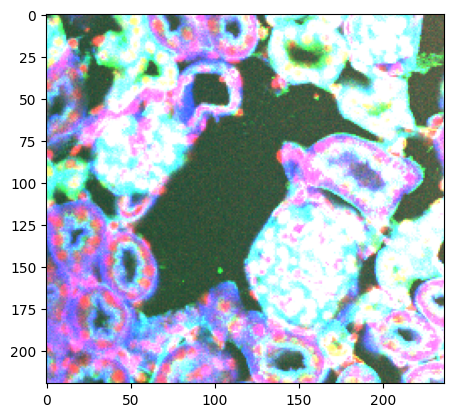

In [9]:
# attempting to crop the region for the rest of the stack 
x_min, y_min, x_max, y_max = bbox_global
fake_maldi = kidney[:, y_min:y_max, x_min:x_max, :]
plt.imshow(fake_maldi[14])

Double checking if the fake maldi data matches the cropped region 

In [10]:
x_min, y_min, x_max, y_max = bbox_global
print("bbox_global =", bbox_global)
print("Width =", x_max - x_min)
print("Height =", y_max - y_min)
plot_bbox_plotly(kidney[1], bbox_global)
plot_bbox_plotly(fake_maldi[1], (0, 0, fake_maldi.shape[2], fake_maldi.shape[1]))


bbox_global = (270, 156, 507, 376)
Width = 237
Height = 220


Now need to make the resolution on the fake MALDI twice as coarse (setting up a simple example)

In [11]:
import numpy as np
from skimage.transform import resize

# 2. Convert entire ROI stack to grayscale in one vectorized call
fake_maldi_gray = rgb2gray(fake_maldi).astype(np.float32)   # shape: (Z, H_roi, W_roi)

# 3. Normalize each plane independently (vectorized)
min_vals = fake_maldi_gray.min(axis=(1,2), keepdims=True)
max_vals = fake_maldi_gray.max(axis=(1,2), keepdims=True)
fake_maldi_gray = (fake_maldi_gray - min_vals) / (max_vals - min_vals + 1e-8)

# 4. Compute target MALDI resolution
target_shape = (fake_maldi_gray.shape[1] // 2, fake_maldi_gray.shape[2] // 2)

# 5. Resize all planes in a loop (cannot vectorize resize)
resized_planes = [
    resize(fake_maldi_gray[z], target_shape, anti_aliasing=True, preserve_range=True).astype(np.float32)
    for z in range(fake_maldi_gray.shape[0])
]

# 6. Stack into a proper MALDI cube (Z, H, W)
resized_maldi_stack = np.stack(resized_planes, axis=0)
resized_maldi_stack.shape # resampled 

(16, 110, 118)

after grey scale they all have the same intensities.....which I don't mind but now we need to random permutaions of half the stack 

In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# number of "maldi" images

n_col = 4

def plot_maldi_grid(stack, n_col):

    n_row = int(np.ceil(stack.shape[0] / n_col))

    fig = make_subplots(
        rows=n_row,
        cols=n_col,
        horizontal_spacing=0.02,
        vertical_spacing=0.02
    )

    for i in range(stack.shape[0]):
        r = i // n_col + 1 # integer division to figure out which image goes to which row
        c = i % n_col + 1 # modulo division to figure out what is the column position of that same image

        plane = np.squeeze(stack[i])

        fig.add_trace(
            go.Heatmap(
                z=plane,
                colorscale="viridis",
                showscale=False
            ),
            row=r,
            col=c
        )

        fig.update_xaxes(showticklabels=False, row=r, col=c)
        fig.update_yaxes(
            showticklabels=False,
            autorange="reversed",
            row=r,
            col=c
        )

    fig.update_layout(
        width=1800,
        height=300 * n_row,
        margin=dict(l=0, r=0, t=0, b=0)
    )

    fig.show()

Now we want to do random shuffling and look at the grid again. We only want to random shuffling on part of the stack...thats it 

(4, 110, 118)
(12, 110, 118)


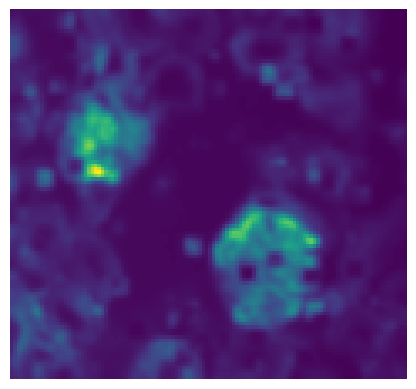

In [13]:
import numpy as np
from scipy.ndimage import gaussian_filter

def shuffle_patches(img, num_patches=8, patch_size=32, sigma=1.0):
    H, W = img.shape
    patches = []
    coords = []

    # 1. Collect random patches
    for _ in range(num_patches):
        y = np.random.randint(0, H - patch_size)
        x = np.random.randint(0, W - patch_size)

        patch = img[y:y+patch_size, x:x+patch_size].copy()
        patches.append(patch)
        coords.append((y, x))

    # 2. Shuffle patch order
    patches = np.array(patches)
    np.random.shuffle(patches)

    # 3. Paste shuffled patches back
    shuffled_img = img.copy()
    for (y, x), patch in zip(coords, patches):
        shuffled_img[y:y+patch_size, x:x+patch_size] = patch

    # 4. Smooth the result
    if sigma > 0:
        shuffled_img = gaussian_filter(shuffled_img, sigma=sigma)

    return shuffled_img
num_rand_shuffle_img = 4
rand_split_maldi = resized_maldi_stack[:num_rand_shuffle_img].copy()
norm_split_maldi = resized_maldi_stack[num_rand_shuffle_img:].copy()

# Shuffle patches in each selected plane
for i in range(rand_split_maldi.shape[0]):
    rand_split_maldi[i] = shuffle_patches(
        rand_split_maldi[i],
        num_patches=70,     # number of patches to shuffle
        patch_size=5,       # patch size
        sigma=1             # smoothing strength
    )

# visualize
plt.imshow(rand_split_maldi[1])
plt.axis("off")

# recombine maldi stack 
print(rand_split_maldi.shape)
print(norm_split_maldi.shape)
#full_fake_maldi =  np.concatenate([rand_split_maldi, norm_split_maldi], axis=0)   
#print(full_fake_maldi.shape)

In [14]:
# combine image stacks 
complete_fake_maldi = np.concatenate([rand_split_maldi, norm_split_maldi], axis=0)

# randomize image order
maldi_img_idx = np.random.permutation(complete_fake_maldi.shape[0])
complete_fake_maldi = complete_fake_maldi[maldi_img_idx]

# confirm whole stack is intact 
complete_fake_maldi.shape

(16, 110, 118)

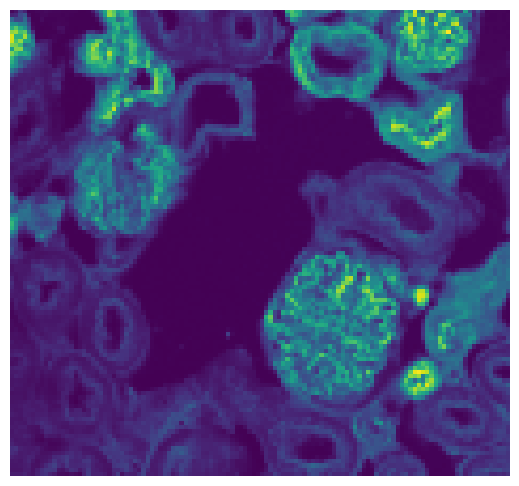

In [15]:
fig = plt.figure(frameon=False)
fig.set_size_inches(5, 5)

ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(complete_fake_maldi[13])

plt.show()

save the maldi image for global alignment

In [16]:
def save_fake_img(img, pic_name, cmap='viridis'):
    plt.figure(frameon=False)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')

    plt.savefig(
        f"/home/kia/MALDI_Metabolomics/kidney_test/{pic_name}.png",
        bbox_inches='tight',
        pad_inches=0
    )
    plt.close()
img = complete_fake_maldi[13]
pic_name = "maldi_test_img"
save_fake_img(img, pic_name)

Save the image that is supposed to be our H&E

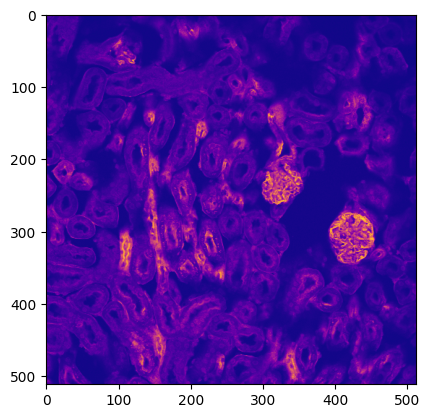

In [17]:
kidney_gray = rgb2gray(kidney).astype(np.float32)
#Normalize each plane independently (vectorized)
min_vals = kidney_gray.min(axis=(1,2), keepdims=True)
max_vals = kidney_gray.max(axis=(1,2), keepdims=True)
kidney_norm = (kidney_gray - min_vals) / (max_vals - min_vals + 1e-8)
plt.imshow(kidney_norm[4], cmap='plasma') # 12 maybe, 11 better, 10 better, 6 seems best 

In [18]:
img = kidney_norm[4]
pic_name = "HE_fake_img"
cmap='plasma'
save_fake_img(img, pic_name, cmap)

### Ran the Global alignment separately, will check this on a Scatter plot 

In [ ]:
import sys
from pathlib import Path

project_root = Path("/home/kia/MALDI_Metabolomics")
sys.path.append(str(project_root))

import scripts.MultimodalRegistration as mr 


IMZML_PATH = "/home/kia/MALDI_Metabolomics/MSI_data_grant/Mass_Spec_data/20251012_old_liver.imzML"
filtered_data = mr.filter_mz_sf_df(imzml_path=IMZML_PATH, targets=[193.4840])
ccs = pd.read_csv('/home/kia/MALDI_Metabolomics/kidney_test/coordinate_mapping.csv')
mr.mz_to_napari_points(signal=filtered_data['mz_193.4840'].values, ccs=ccs, col_x='he_x', col_y='he_y', 
                       he_path='/home/kia/MALDI_Metabolomics/high_res_MSI/D2_10x_originalExport.tif',
                       point_size=6)


Rendering 269,511 points total, 262,640 with signal



(python:19544): GLib-CRITICAL **: 17:57:11.923: g_main_context_pop_thread_default: assertion 'stack != NULL' failed

(python:19544): GLib-CRITICAL **: 17:57:40.693: g_main_context_pop_thread_default: assertion 'stack != NULL' failed

(python:19544): GLib-CRITICAL **: 17:57:40.693: g_main_context_pop_thread_default: assertion 'stack != NULL' failed

(python:19544): GLib-CRITICAL **: 17:57:40.693: g_main_context_pop_thread_default: assertion 'stack != NULL' failed

(python:19544): GLib-CRITICAL **: 17:57:40.693: g_main_context_pop_thread_default: assertion 'stack != NULL' failed

(python:19544): GLib-CRITICAL **: 17:57:40.693: g_main_context_pop_thread_default: assertion 'stack != NULL' failed

(python:19544): GLib-CRITICAL **: 17:57:40.693: g_main_context_pop_thread_default: assertion 'stack != NULL' failed

(python:19544): GLib-CRITICAL **: 17:57:40.693: g_main_context_pop_thread_default: assertion 'stack != NULL' failed

(python:19544): GLib-CRITICAL **: 17:57:40.693: g_main_context_